# Modeling and Valuation of Swing Options

This project aims to model and price complex electricity supply contracts, specifically **Swing Options**. In an electricity market characterized by high volatility and the non-storable nature of the underlying asset, these instruments play a crucial role in volume risk hedging.

### 1. The Swing Product: Flexibility under Constraints
As defined by **Jaillet, Ronn, and Tompaidis (2004)**, the fundamental value of a Swing option lies in the volume flexibility offered to the buyer. Unlike a standard single-exercise option (such as European or American options), a Swing contract allows the holder to adjust the quantity of energy consumed at multiple times $t_1, t_2, \dots, t_n$ throughout the life of the contract.

However, this freedom of exercise is bound by two levels of strict constraints:
* **Local Constraints (Daily):** Limits on instantaneous power or daily volume ($q_{min} \leq q_t \leq q_{max}$).
* **Global Constraints (Cumulative):** Limits on the total volume consumed over the entire duration of the contract ($Q_{min} \leq \sum u_t \leq Q_{max}$).



### 2. Methodology and Modeling Choices
To capture the complex dynamics of electricity prices and value this path-dependent option, we adopt a **Monte Carlo Simulation** approach.

* **The MRJD Model:** We model the electricity spot price ($S_t$) using a **Mean-Reverting Jump Diffusion** process. This choice relies on the seminal work of **Cartea and Figueroa (2005)**, enabling the reproduction of two major market characteristics: the mean-reverting force towards marginal production costs and violent price spikes.
* **Robust Calibration:** The parameter calibration methodology ($\alpha, \sigma, \lambda, \dots$) follows the recommendations of the empirical study by **Benth, Kiesel, and Nazarova (2012)**, particularly regarding seasonality filtering and the treatment of extreme values.



### 3. Project Structure
This report is structured around two main axes:

1.  **Part I: Stochastic Modeling.** Analysis of historical data, deseasonalization, jump filtering, and calibration of the MRJD process parameters.
2.  **Part II: Pricing and Analysis.** Implementation of the valuation algorithm (based on **Longstaff-Schwartz / LSM** to handle optimal exercise strategy) and sensitivity analysis of the Swing premium.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import copy
import scipy.stats as stats
from scipy.interpolate import interp1d

## I. Spot Modeling

### 1. Data

#### A. Futures

To ensure our model respects market expectations and allows for arbitrage-free pricing, we incorporate **Futures prices**. These contracts provide the market's consensus on future delivery prices and are essential for constructing the **Forward Curve** $\Lambda(t)$.

**Missing Data Handling (`ffill`):** In financial time series, missing values (often due to holidays or illiquidity) are typically handled via **Forward Filling**. This propagates the last known transaction price, reflecting that information remains constant until a new trade occurs.

**Temporal Filtering:** We restrict the dataset to the calibration window (up to `2023-01-01`) to align with our Spot data analysis.

In [2]:
future = pd.read_excel("data/futures.xlsx", header=0)

In [3]:
future["date"]= pd.to_datetime(future["date"])
future.ffill(inplace=True)
future = future[future['date'] <= "2023-01-01"]
future.head()

,date,TRFRBYc1,TRFRBMc1,TRFRBFVMG6,TRFRBFVMH6,TRFRBFVMJ6,TRFRBFVMK6,TRFRBFVMM6,TRFRBFVMN6,TRFRBFVMQ6,...,TRFRBFVMH7,TRFRBFVMJ7,TRFRBFVMK7,TRFRBFVMM7,TRFRBFVMN7,TRFRBFVMQ7,TRFRBFVMU7,TRFRBFVMV7,TRFRBFVMX7,TRFRBFVMZ7
789,2022-12-30,245.00,202.0,162.85,147.12,115.84,103.95,101.40,102.91,110.96,...,135.40,105.99,92.64,92.72,94.45,100.84,117.78,152.02,163.86,162.26
790,2022-12-29,269.75,230.0,161.31,145.57,114.32,102.43,99.88,101.27,109.32,...,134.56,104.78,91.57,91.86,93.21,99.71,116.73,151.04,162.93,161.33
791,2022-12-28,274.00,240.0,166.20,151.23,109.20,99.74,97.55,98.32,106.83,...,141.58,99.22,88.97,90.63,91.19,97.40,112.55,159.32,168.87,166.42
792,2022-12-27,276.00,266.0,168.71,153.69,108.19,98.71,96.48,97.22,105.71,...,143.68,98.29,88.26,89.80,90.48,96.64,111.50,158.52,168.02,165.58
793,2022-12-26,276.00,266.0,166.46,156.30,95.84,93.83,91.22,90.94,101.84,...,139.45,78.74,78.48,80.38,79.59,86.55,93.88,158.16,158.22,156.62


#### B. Spot Price

The raw dataset comprises hourly **Day-Ahead** prices from 2016 to 2026. For the purpose of this Swing option pricing—which typically involves daily volume constraints—we aggregate the data into a **Daily Average Price** (Baseload).

$$S_t^{daily} = \frac{1}{24} \sum_{h=1}^{24} S_{t,h}$$

In [4]:
# Reading and processing files Spot22, Spot23, Spot24, Spot25
spot_files = ["data/spot_price_16.xlsx","data/spot_price_17.xlsx","data/spot_price_18.xlsx","data/spot_price_19.xlsx","data/spot_price_20.xlsx","data/spot_price_21.xlsx","data/spot_price_22.xlsx", "data/spot_price_23.xlsx", "data/spot_price_24.xlsx", "data/spot_price_25.xlsx"]
spot_data = []

for file in spot_files:
    spot = pd.read_excel(file)
    spot['Date'] = spot['Date'].str.split(' - ').str[0]  # Take only the start of the range
    spot['Date'] = pd.to_datetime(spot['Date'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
    spot = spot.dropna(subset=['Date'])  # Drop rows with invalid dates
    daily = spot.groupby(spot['Date'].dt.date)['Day-ahead'].mean().reset_index()
    daily.rename(columns={'Date': 'date', 'Day-ahead': 'price'}, inplace=True)
    spot_data.append(daily)

# Merging datasets
spot_merged = pd.concat(spot_data).groupby('date', as_index=False)['price'].mean()
# Displaying the first rows of the result
spot_merged.head()

,date,price
0,2016-01-01,23.888750
1,2016-01-02,23.198750
2,2016-01-03,18.003750
3,2016-01-04,28.229583
4,2016-01-05,33.877083


In [5]:
spot_merged.loc[spot_merged['price'] <= 0, 'price'] = np.nan
spot_merged['price'] = spot_merged['price'].ffill()

The plot below illustrates the full history of the French power market. We can clearly distinguish three regimes:
1.  **Pre-Crisis (2016-2020):** Stable prices, typically mean-reverting around 40-50 €/MWh.
2.  **Energy Crisis (2021-2022):** Extreme volatility and structural break, with peaks exceeding 700 €/MWh due to geopolitical tensions and nuclear availability issues.
3.  **Post-Crisis / New Normal (2023+):** Prices have receded from the peaks but exhibit a different volatility structure than the pre-2020 era.

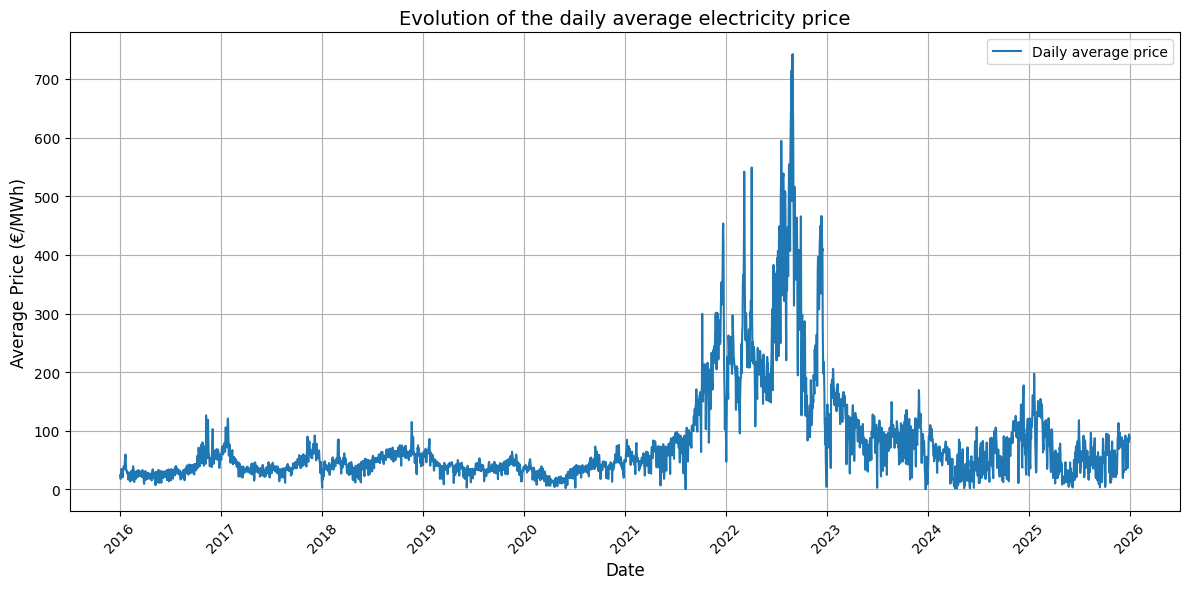

In [6]:
plt.figure(figsize=(12, 6))
# Plot the daily average price over time
plt.plot(spot_merged['date'], spot_merged['price'], linestyle='-', label='Daily average price')
plt.title("Evolution of the daily average electricity price", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price (€/MWh)", fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Convert the 'date' column to datetime64 type to avoid type incompatibilities
spot_merged['date'] = pd.to_datetime(spot_merged['date'])

# Filter the data to keep only dates starting from January 1st, 2023
spot_merged = spot_merged[spot_merged['date'] >= pd.Timestamp('2023-01-01')]

To avoid biasing the MRJD parameters with the extreme outliers of the 2022 crisis (which might overestimate the mean-reversion level $\alpha$ and volatility $\sigma$), we restrict the calibration window to the **post-crisis regime**.

We select the period starting **January 1st, 2023**. This dataset will be used to fit the seasonality and stochastic parameters.

In [8]:
# Convert the 'date' column to datetime64 type to avoid type incompatibilities
spot_merged['date'] = pd.to_datetime(spot_merged['date'])

# Filter the data to keep only dates starting from January 1st, 2023
spot_merged = spot_merged[spot_merged['date'] >= pd.Timestamp('2023-01-01')]

In [9]:
# Add "day", "month", "week", and "season" columns
spot_merged['jour'] = spot_merged['date'].dt.day_name()
spot_merged['mois'] = spot_merged['date'].dt.month_name()
spot_merged['semaine'] = spot_merged['date'].dt.isocalendar().week
spot_merged['saison'] = spot_merged['date'].dt.month % 12 // 3 + 1
spot_merged['saison'] = spot_merged['saison'].map({1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'})

Before calibrating the deterministic trend $\mu(t)$ and the stochastic parameters, it is crucial to understand the structural behaviors of the electricity spot price. We analyze the dataset across different time scales to identify **periodicities** and **heteroscedasticity** (time-varying variance).

### A. Weekly Seasonality (The "Weekend Effect")
Electricity demand is strongly correlated with economic activity.
* **Observation:** As shown in the bar charts, prices consistently drop during the weekend (Saturday and Sunday) compared to business days.
* **Distribution:** The boxplots reveal that while the median price is lower on weekends, the variance (interquartile range) remains significant, indicating that low demand does not preclude volatility.

### B. Annual Seasonality (The "Meteo Effect")
The French market is highly sensitive to temperature due to the prevalence of electric heating.
* **Trend:** We observe a clear annual cycle with peaks in **Winter** (Jan-Feb) and troughs in late Spring/early Summer.
* **Volatility Clustering:** The monthly boxplots illustrate that volatility is not constant. Winter months exhibit not only higher means but also "fatter tails" (more extreme outliers), validating the need for a **Jump Diffusion** component that is potentially seasonally modulated.


The following code computes descriptive statistics and generates visualizations to confirm these stylized facts, which underpin the choice of the truncated Fourier series for $\mu(t)$.

Descriptive statistics by day of the week:
           count       mean        std        min        25%        50%  \
jour                                                                      
Friday     156.0  77.547948  37.992099   6.008333  54.388229  78.793073   
Monday     157.0  76.072197  40.311244   0.600000  46.892917  73.590417   
Saturday   156.0  61.733245  36.331542   1.858750  31.779896  56.751875   
Sunday     157.0  51.744751  37.181654   0.597500  19.778750  45.536667   
Thursday   156.0  79.254841  39.663877   7.231667  52.840833  80.168281   
Tuesday    157.0  79.423432  40.004813   1.659167  49.847917  77.178333   
Wednesday  157.0  80.163034  38.417830  13.785417  51.245417  82.275833   

                  75%         max  
jour                               
Friday      99.009062  187.445833  
Monday     101.276667  205.830000  
Saturday    86.250208  156.182500  
Sunday      74.291250  167.334167  
Thursday   105.515104  185.080833  
Tuesday    105.366250  204.69

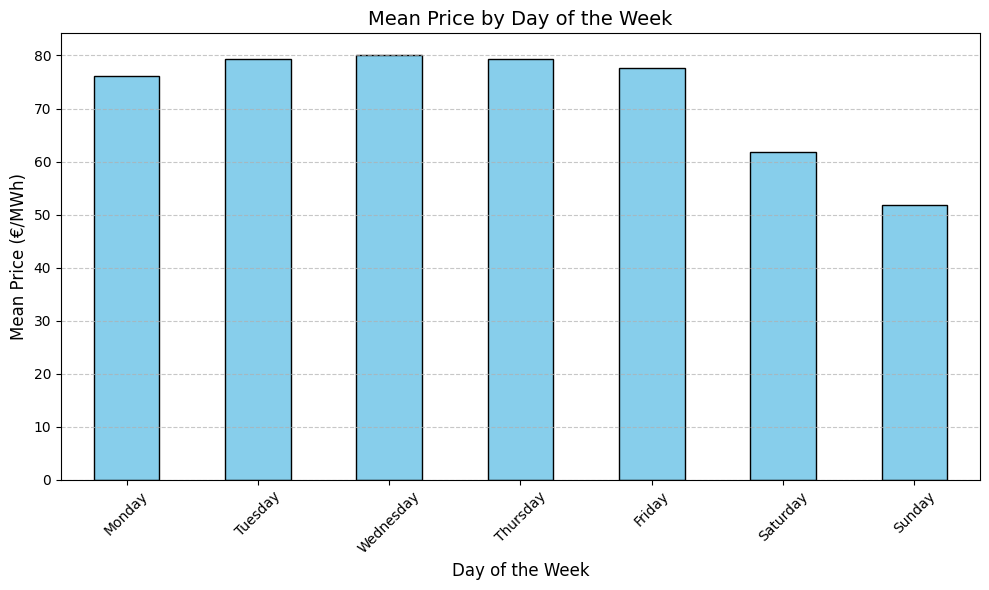

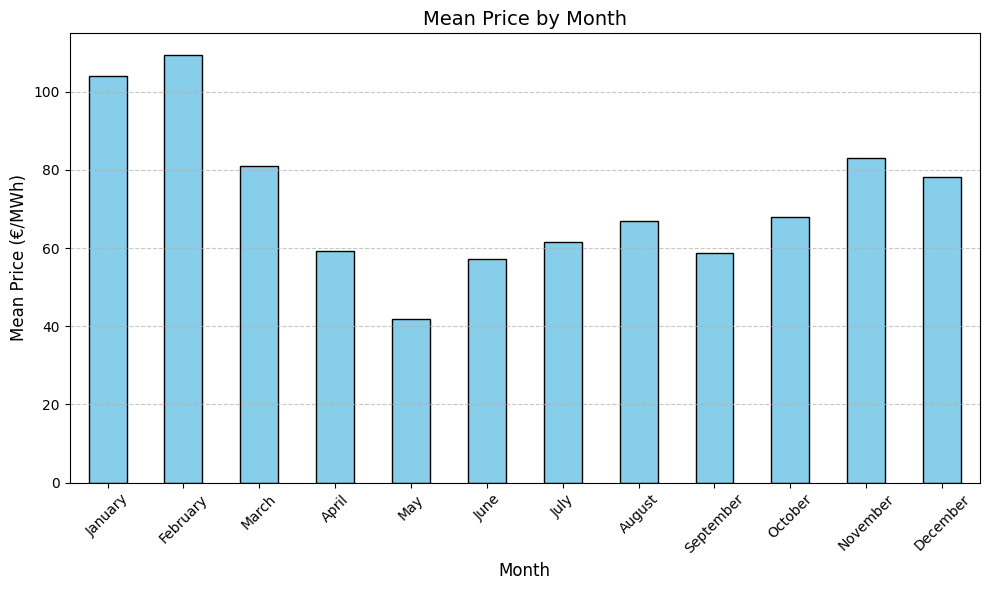

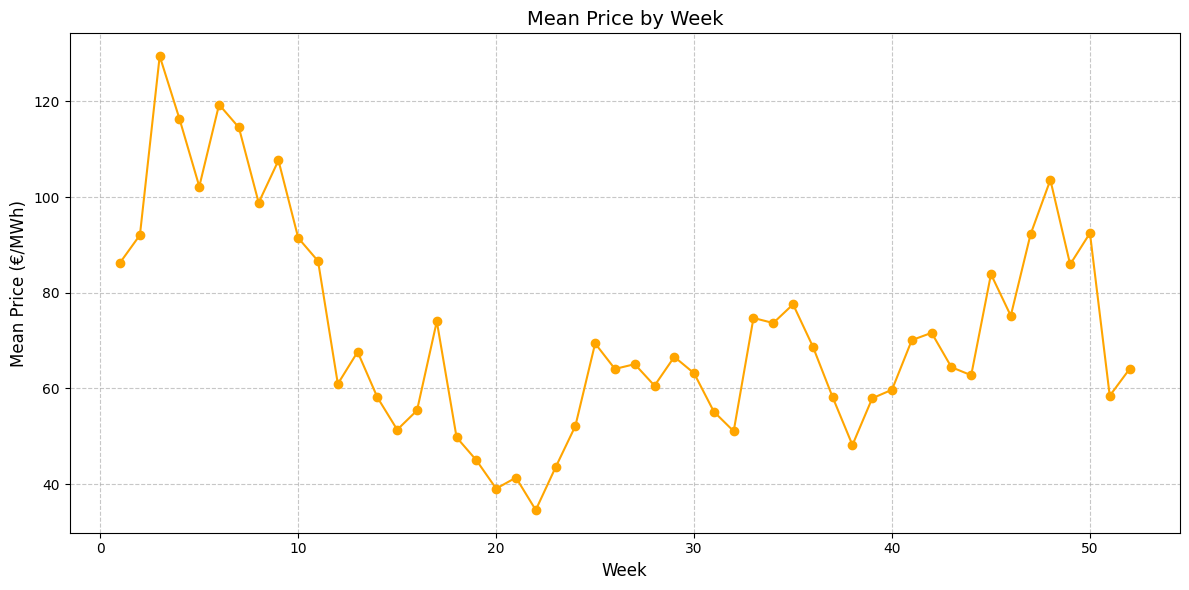

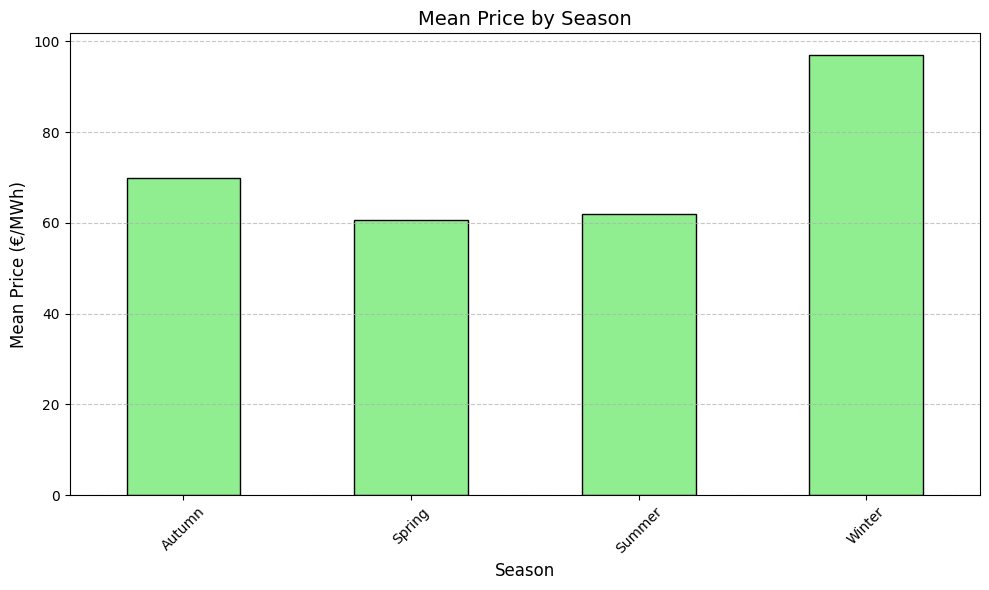

<Figure size 1200x800 with 0 Axes>

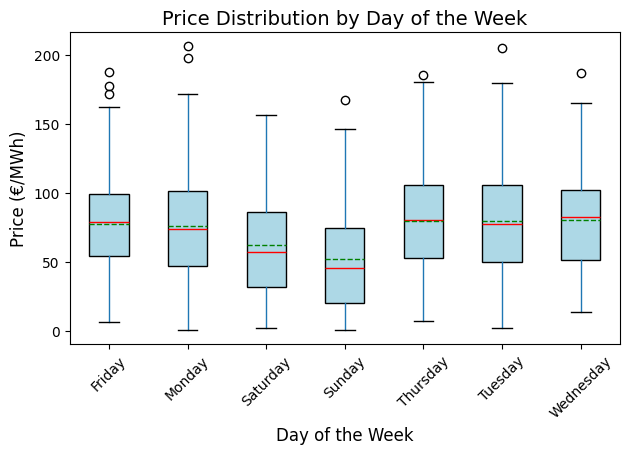

<Figure size 1200x800 with 0 Axes>

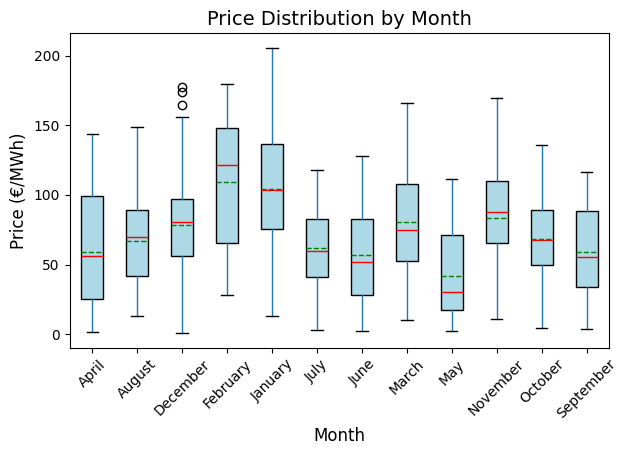

<Figure size 1200x800 with 0 Axes>

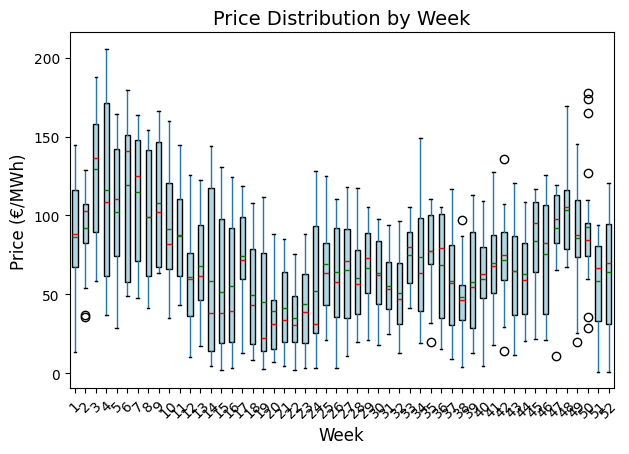

<Figure size 1200x800 with 0 Axes>

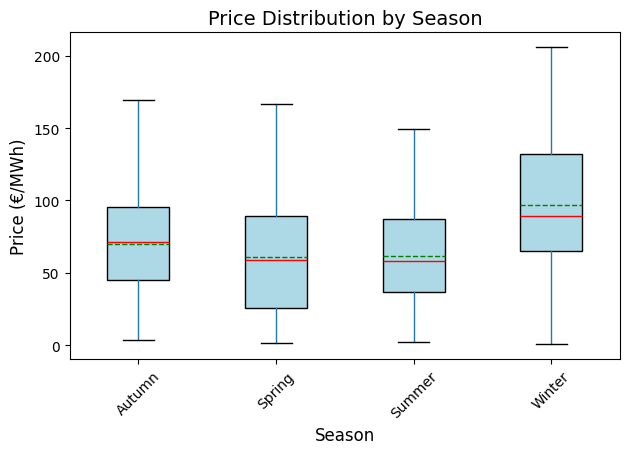

In [10]:
# Descriptive statistics to measure seasonality by day, month, week, and season
stats_by_day = spot_merged.groupby('jour')['price'].describe()
stats_by_month = spot_merged.groupby('mois')['price'].describe()
stats_by_week = spot_merged.groupby('semaine')['price'].describe()
stats_by_season = spot_merged.groupby('saison')['price'].describe()

print("Descriptive statistics by day of the week:")
print(stats_by_day)
print("\nDescriptive statistics by month:")
print(stats_by_month)
print("\nDescriptive statistics by week:")
print(stats_by_week)
print("\nDescriptive statistics by season:")
print(stats_by_season)

# Chart of mean prices by day of the week
plt.figure(figsize=(10, 6))
spot_merged.groupby('jour')['price'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Mean Price by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Mean Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Chart of mean prices by month
plt.figure(figsize=(10, 6))
spot_merged.groupby('mois')['price'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
]).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Mean Price by Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Mean Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Chart of mean prices by week
plt.figure(figsize=(12, 6))
spot_merged.groupby('semaine')['price'].mean().plot(color='orange', linestyle='-', marker='o')
plt.title("Mean Price by Week", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Mean Price (€/MWh)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Chart of mean prices by season
plt.figure(figsize=(10, 6))
spot_merged.groupby('saison')['price'].mean().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Mean Price by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Mean Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Chart of price distribution by day of the week
plt.figure(figsize=(12, 8))
spot_merged.boxplot(column='price', by='jour', grid=False, showmeans=True, meanline=True,
                    patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'), meanprops=dict(color='green'))
plt.title("Price Distribution by Day of the Week", fontsize=14)
plt.suptitle("")  # Remove default boxplot title
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart of price distribution by month
plt.figure(figsize=(12, 8))
spot_merged.boxplot(column='price', by='mois', grid=False, showmeans=True, meanline=True,
                    patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'), meanprops=dict(color='green'))
plt.title("Price Distribution by Month", fontsize=14)
plt.suptitle("")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart of price distribution by week
plt.figure(figsize=(12, 8))
spot_merged.boxplot(column='price', by='semaine', grid=False, showmeans=True, meanline=True,
                    patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'), meanprops=dict(color='green'))
plt.title("Price Distribution by Week", fontsize=14)
plt.suptitle("")
plt.xlabel("Week", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart of price distribution by season
plt.figure(figsize=(12, 8))
spot_merged.boxplot(column='price', by='saison', grid=False, showmeans=True, meanline=True,
                    patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'), meanprops=dict(color='green'))
plt.title("Price Distribution by Season", fontsize=14)
plt.suptitle("")
plt.xlabel("Season", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On calcule les log-prix et la position temporelle dans l'année

In [11]:
spot_merged['log_price'] = np.log(spot_merged['price'])
spot_merged['t_years'] = np.arange(len(spot_merged)) / 365

### 2. Deseasonalization and Filtering (Benth et al. 2012 Method)

To extract the deterministic component (seasonality + trend) while preventing extreme price peaks (*spikes*) from biasing the estimation, we follow the methodology described by **Benth, Kiesel & Nazarova**. Unlike a simple Fourier series, this approach incorporates a linear trend and data pre-processing.

#### A. Trend Model $\mu(t)$
The selected trend function includes a linear component (to capture the structural evolution of costs) and two harmonics (annual and semi-annual):

$$
\mu(t) = \alpha + \beta t + \gamma \cos(\epsilon + 2\pi t) + \delta \cos(\zeta + 4\pi t)
$$

Where:
* $\alpha$: Base level (fixed production cost).
* $\beta t$: Long-term linear trend (inflation, fuel switching).
* $\gamma, \epsilon$: Amplitude and phase of the **annual** seasonality (12 months).
* $\delta, \zeta$: Amplitude and phase of the **semi-annual** seasonality (capturing winter/summer variations).

#### B. Calibration Algorithm (Prior Filtering)
The authors emphasize that the presence of violent *spikes* can skew Least Squares estimation. The calibration procedure consists of three steps:

1. **Smoothing:** Calculation of a centered moving average over a sliding window of **30 days**.
2. **Outlier Filtering:** If the absolute deviation between the actual log-price and the moving average exceeds a threshold of **0.5**, the value is considered an *outlier* and is replaced by the smoothed average. This substitution is temporary and serves only for calibration purposes.
3. **Estimation:** The parameters of $\mu(t)$ are estimated on this "cleaned" series via a Non-linear Least Squares (NLS) fit.

Once the trend $\mu(t)$ is calibrated, the deseasonalized stochastic series $X_t$ is obtained by subtracting the trend from the **original prices** (retaining the spikes):

$$
X_t = \ln(S_t) - \mu(t)
$$

Préfiltrage

In [12]:
# Calculation of the moving average
window_size = 30
spot_merged['log_price_smooth'] = spot_merged['log_price'].rolling(window=window_size, center=True, min_periods=1).mean()

# Replacement of outliers for calibration
# We create a temporary series specifically for fitting the trend
spot_merged['log_price_for_fit'] = spot_merged['log_price'].copy()

# Outlier mask
outlier_mask = np.abs(spot_merged['log_price'] - spot_merged['log_price_smooth']) > 0.5
num_filtered = outlier_mask.sum()

# Replacement
spot_merged.loc[outlier_mask, 'log_price_for_fit'] = spot_merged.loc[outlier_mask, 'log_price_smooth']

In [13]:
# mu(t) = alpha + gamma*cos(epsilon + 2*pi*t) + delta*cos(zeta + 4*pi*t)
def seasonality_func(t, alpha, gamma, epsilon, delta, zeta):
    term1 = alpha
    term2 = gamma * np.cos(epsilon + 2 * np.pi * t) # Annual seasonality
    term3 = delta * np.cos(zeta + 4 * np.pi * t)    # Semi-annual seasonality
    return term1 + term2 + term3

# Initial guess for the parameters
p0_guess = [
    spot_merged['log_price'].mean(),
    0.0, 0.0,
    0.2, 0.0
]

# Optimization using Non-linear Least Squares
params_opt, params_cov = curve_fit(
    seasonality_func,
    spot_merged['t_years'].values,
    spot_merged['log_price_for_fit'].values,
    p0=p0_guess
)

# Extracting optimized parameters
alpha_fit, gamma_fit, eps_fit, delta_fit, zeta_fit = params_opt
print(f"Alpha : {alpha_fit:.4f}")
print(f"Gamma : {gamma_fit:.4f}")
print(f"Epsilon : {eps_fit:.4f}")
print(f"Delta : {delta_fit:.4f}")
print(f"Zeta : {zeta_fit:.4f}")

Alpha : 4.1170
Gamma : 0.3647
Epsilon : 0.1875
Delta : 0.2579
Zeta : -1.1414


In [14]:
# Calculating the seasonality trend
spot_merged['seasonality_trend'] = seasonality_func(spot_merged['t_years'].values, *params_opt)

# Subtracting the trend from the original log-prices
# Xt = log(St) - mu(t)
spot_merged['Xt'] = spot_merged['log_price'] - spot_merged['seasonality_trend']

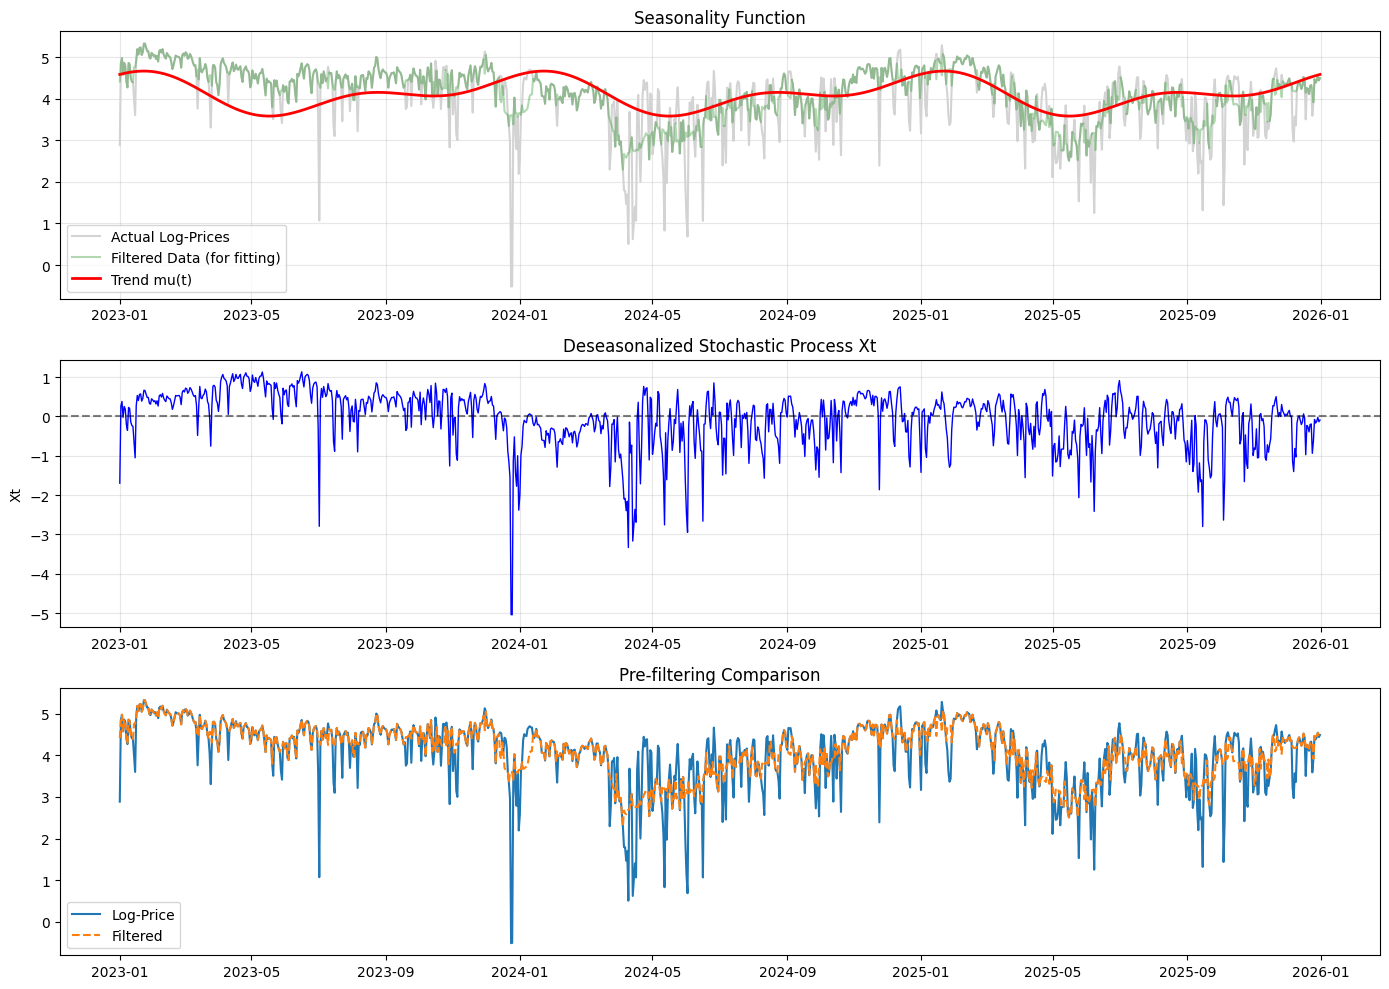

In [15]:
plt.figure(figsize=(14, 10))

# Original Prices vs Estimated Trend
plt.subplot(3, 1, 1)
plt.plot(spot_merged['date'], spot_merged['log_price'], color='lightgray', label='Actual Log-Prices')
plt.plot(spot_merged['date'], spot_merged['log_price_for_fit'], color='green', alpha=0.3, label='Filtered Data (for fitting)')
plt.plot(spot_merged['date'], spot_merged['seasonality_trend'], color='red', linewidth=2, label='Trend mu(t)')
plt.title("Seasonality Function")
plt.legend()
plt.grid(True, alpha=0.3)

# Deseasonalized Process Xt
plt.subplot(3, 1, 2)
plt.plot(spot_merged['date'], spot_merged['Xt'], color='blue', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Deseasonalized Stochastic Process Xt")
plt.ylabel("Xt")
plt.grid(True, alpha=0.3)

# Filtering Comparison
plt.subplot(3, 1, 3)
plt.plot(spot_merged['date'], spot_merged['log_price'], label='Log-Price')
plt.plot(spot_merged['date'], spot_merged['log_price_for_fit'], label='Filtered', linestyle='--')
plt.title("Pre-filtering Comparison")
plt.legend()

plt.tight_layout()
plt.show()

### 3. Jump Detection and Filtering (Recursive Algorithm)

Once the seasonal component is removed, we obtain the stochastic process $X_t$. This process is modeled as a **Mean-Reverting Jump Diffusion**. To accurately calibrate $\sigma$ without it being biased by extreme values, it is essential to separate the jumps from the "normal noise."

We apply the iterative filtering method described by **Cartea & Figueroa (2005)** and adopted by **Benth et al. (2012)**.

#### Detection Algorithm
The principle is based on the **"3-sigma" rule** applied recursively:

1. **Initialization**: Calculate the mean $\mu$ and the standard deviation $\sigma$ of the daily variations $\Delta X_t = X_t - X_{t-1}$.
2. **Identification**: Identify points where the absolute variation exceeds a critical threshold (set at $3\sigma$):
   $$|\Delta X_t - \mu| > 3\sigma$$
3. **Extraction**: Consider these points as **jumps** ($J$) and temporarily remove them from the sample.
4. **Iteration**: Re-calculate $\mu$ and $\sigma$ on the remaining series. As extreme values are removed, $\sigma$ decreases, allowing the detection of smaller jumps in the next iteration.
5. **Termination**: The algorithm stops when no new jumps are detected.



Upon completion of this process, we obtain two distinct datasets:
* A **"cleaned" series** (the pure diffusion) used to estimate the volatility $\sigma$ and the mean-reversion speed $\kappa$.
* A **series of isolated jumps** used to estimate the jump frequency $\lambda$ and the distribution of amplitudes $(\mu_J, \sigma_J)$.

In [16]:
# Daily variations of the deseasonalized process Xt
# dx corresponds approximately to X(t+1) - X(t)
dx = spot_merged['Xt'].diff().dropna()

clean_dx = dx.copy()
jumps_indices = []
iteration = 0
SIGMA_THRESHOLD = 3.0

while True:
    iteration += 1
    mu = clean_dx.mean()
    std = clean_dx.std()

    # Detection criterion: Variation > 3 * current standard deviation
    # We use the absolute value
    is_jump = np.abs(clean_dx - mu) > SIGMA_THRESHOLD * std

    # Termination condition: If no new jumps are found, we stop
    if not is_jump.any():
        break

    # Save the identified jumps
    new_jumps = clean_dx[is_jump]
    jumps_indices.extend(new_jumps.index)

    # Filter out the jumps for the next iteration
    clean_dx = clean_dx[~is_jump]

# Results
print(f"Iterations: {iteration}")
print(f"Total jumps detected: {len(jumps_indices)}")

# Mark the jumps in the main DataFrame for future use
spot_merged['is_jump'] = False
spot_merged.loc[jumps_indices, 'is_jump'] = True

Iterations: 9
Total jumps detected: 53


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/1975482817.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.scatter(spot_merged.loc[jumps_indices, 'date'], dx[jumps_indices], color='red', marker='x', s=40, label='Detected Jumps (> 3$\sigma$)', zorder=5)
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/1975482817.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(threshold_up, color='green', linestyle='--', alpha=0.8, label=f'Threshold (+{SIGMA_THRESHOLD}$\sigma$)')
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/1975482817.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(threshold_down, color='green', 

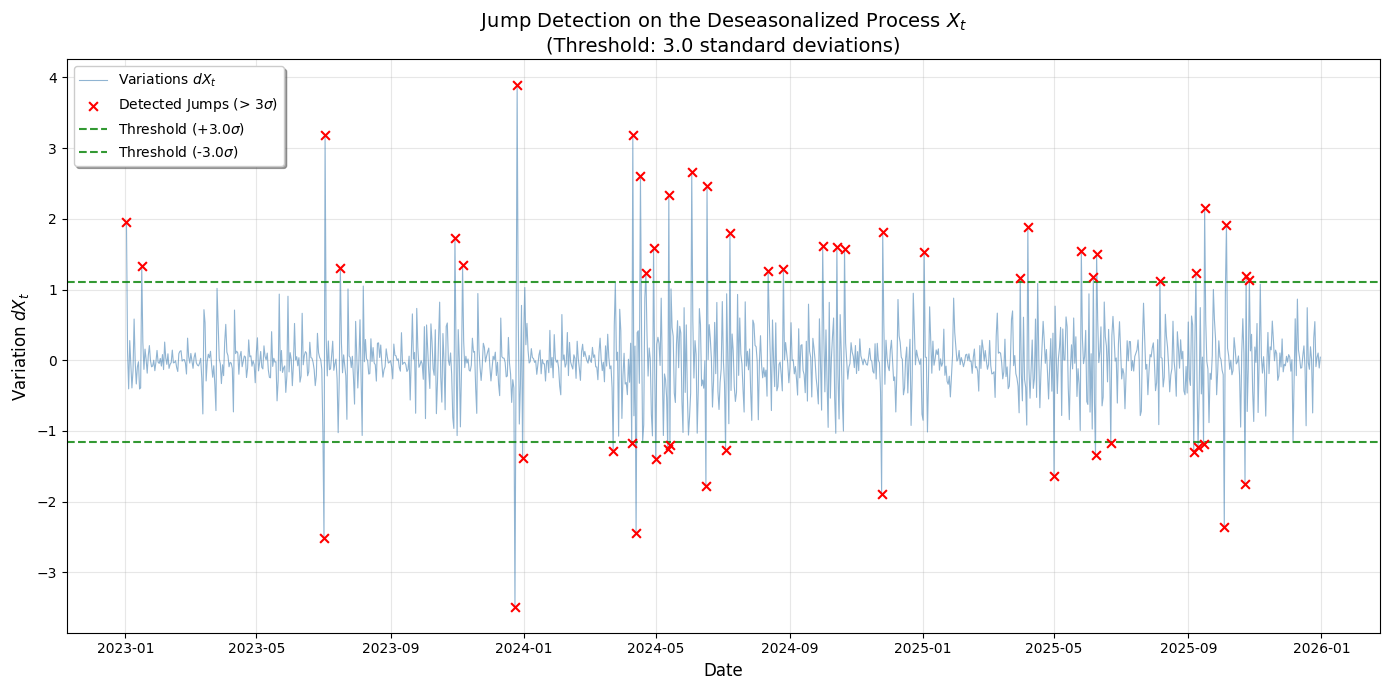

In [17]:
final_std = clean_dx.std()
final_mu = clean_dx.mean()
threshold_up = final_mu + SIGMA_THRESHOLD * final_std
threshold_down = final_mu - SIGMA_THRESHOLD * final_std

plt.figure(figsize=(14, 7))

# Plotting the variations and the identified jumps
plt.plot(spot_merged['date'].iloc[1:], dx, color='steelblue', alpha=0.6, linewidth=0.8, label='Variations $dX_t$')
plt.scatter(spot_merged.loc[jumps_indices, 'date'], dx[jumps_indices], color='red', marker='x', s=40, label='Detected Jumps (> 3$\sigma$)', zorder=5)

# Adding the detection thresholds
plt.axhline(threshold_up, color='green', linestyle='--', alpha=0.8, label=f'Threshold (+{SIGMA_THRESHOLD}$\sigma$)')
plt.axhline(threshold_down, color='green', linestyle='--', alpha=0.8, label=f'Threshold (-{SIGMA_THRESHOLD}$\sigma$)')

plt.title(f"Jump Detection on the Deseasonalized Process $X_t$\n(Threshold: {SIGMA_THRESHOLD} standard deviations)", fontsize=14)
plt.ylabel("Variation $dX_t$", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Number of jumps: 53
Intensity (lambda): 17.67 jumps/year
Mean amplitude (mu_J): 0.4957
Jump volatility (sigma_J): 1.8092


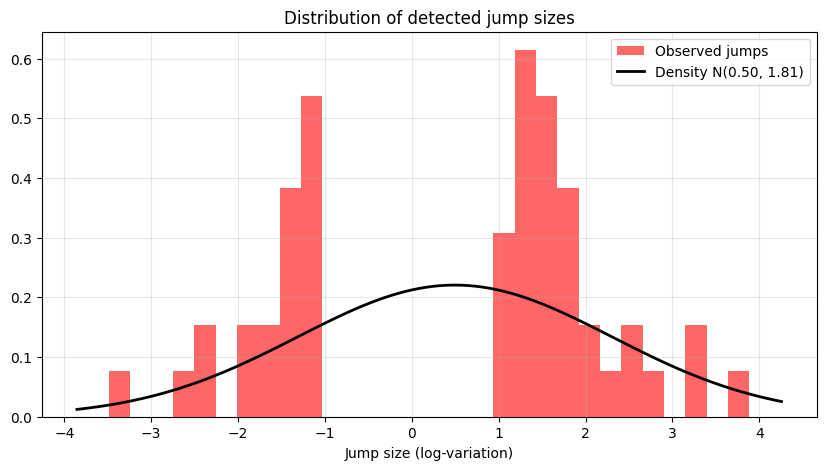

In [18]:
# Extract the values of the detected jumps
jump_values = dx.loc[jumps_indices]

# Estimation of the distribution of jump amplitudes
mu_J = jump_values.mean()
sigma_J = jump_values.std()

# Estimation of the jump intensity (frequency per year)
nb_years = (spot_merged['date'].max() - spot_merged['date'].min()).days / 365
lambda_J = len(jump_values) / nb_years

print(f"Number of jumps: {len(jump_values)}")
print(f"Intensity (lambda): {lambda_J:.2f} jumps/year")
print(f"Mean amplitude (mu_J): {mu_J:.4f}")
print(f"Jump volatility (sigma_J): {sigma_J:.4f}")

# Visualization of the jump distribution (Histogram)
import scipy.stats as stats

plt.figure(figsize=(10, 5))
# Histogram of identified jumps
count, bins, ignored = plt.hist(jump_values, bins=30, density=True, alpha=0.6, color='red', label='Observed jumps')

# Theoretical Normal Curve for comparison
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_J, sigma_J)
plt.plot(x, p, 'k', linewidth=2, label=f'Density N({mu_J:.2f}, {sigma_J:.2f})')

plt.title("Distribution of detected jump sizes")
plt.xlabel("Jump size (log-variation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4. Volatility Modeling $\sigma$ (Constant Approximation)

While **Benth et al. (2012)** discuss the existence of seasonal volatility patterns in electricity markets (higher volatility in winter due to demand tension), implementing a fully time-dependent volatility function introduces significant complexity and potential overfitting.

For this implementation, we opt for a **Constant Volatility** approach for the diffusive part of the process. This assumption implies that while the *price level* follows a strong seasonal trend and *spikes* occur randomly, the underlying "nervousness" (noise) of the market remains relatively stable on average once these factors are removed.

#### Methodology
1. **Jump Filtering:** We ensure that extreme jumps do not contaminate the estimation of the diffusive volatility. Returns exceeding $3\sigma$ are temporarily neutralized (set to $0$).
2. **Rolling Volatility:** We calculate the historical standard deviation on a sliding window of **30 days** to observe market dynamics.
   $$\sigma_{rolling}(t) = \sqrt{\text{Var}(dX_{t-30:t})} \times \sqrt{365}$$
3. **Averaging:** The final parameter $\sigma_{flat}$ is obtained by taking the mean of this rolling series over the entire observation period.
   $$\sigma_{flat} = \mathbb{E}[\sigma_{rolling}(t)]$$

<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/3826117489.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(y=sigma_flat, color='red', linewidth=2, linestyle='--', label=f'Flat Model ($\sigma$={sigma_flat:.2%})')


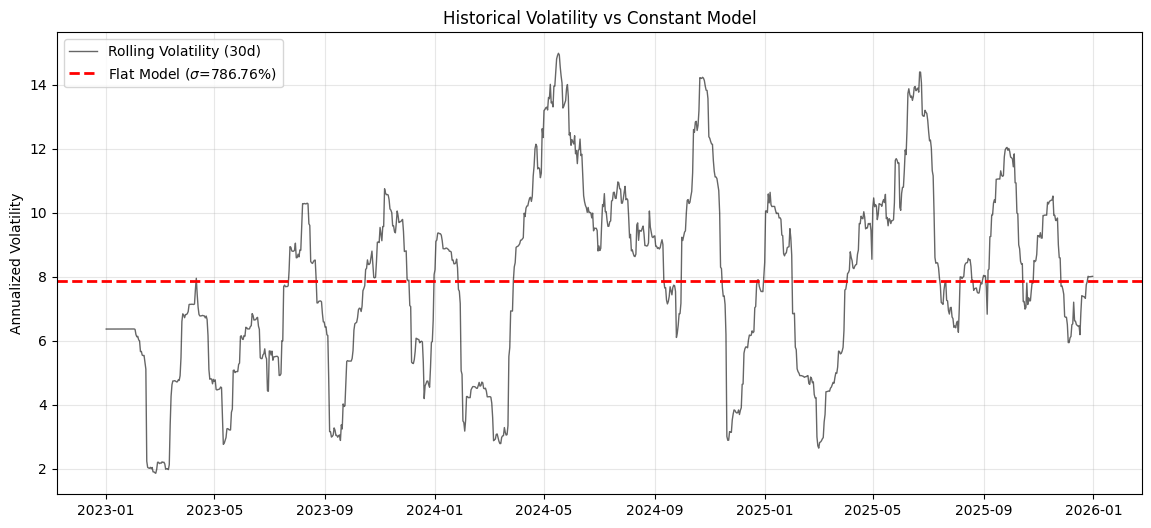

Flat Volatility: 7.867588328441074


In [19]:
# Sort and reset index to ensure time continuity
spot_merged = spot_merged.sort_values('date').reset_index(drop=True)
dY = spot_merged['Xt'].diff()

# --- Volatility Filtering ---
clean_dY = dY.copy()
std_base = clean_dY.std()

# Identify jumps (threshold > 3 sigma)
is_jump = np.abs(clean_dY) > 3 * std_base

# Neutralize jumps to avoid skewing the diffusive volatility calculation
# We set them to 0.0 to remove their variance contribution
clean_dY[is_jump] = 0.0

# --- Rolling Volatility Calculation ---
WINDOW_VOL = 30
# Calculate rolling std dev and annualize it (sqrt(365))
vol_rolling = clean_dY.rolling(window=WINDOW_VOL).std() * np.sqrt(365)
vol_rolling = vol_rolling.bfill().ffill() # Handle NaNs (fill gaps at edges)

# --- Flat Volatility Model (Mean) ---
sigma_flat = vol_rolling.mean()

# --- Visualization ---
plt.figure(figsize=(14, 6))

dates_aligned = spot_merged.loc[vol_rolling.index, 'date']

plt.plot(dates_aligned, vol_rolling, color='black', linewidth=1, alpha=0.6, label='Rolling Volatility (30d)')
plt.axhline(y=sigma_flat, color='red', linewidth=2, linestyle='--', label=f'Flat Model ($\sigma$={sigma_flat:.2%})')

plt.title("Historical Volatility vs Constant Model")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Flat Volatility: {sigma_flat}")

### 5. Calibration of Mean Reversion ($\alpha$)

We calibrate the mean reversion parameter $\alpha$ following the approach of **Cartea & Figueroa (2005)**. A linear regression is performed on the complete deseasonalized series $X_t$:

$$X_t = \beta X_{t-1} + \epsilon_t$$

In this specification, the error term $\epsilon_t$ captures both the diffusion (Brownian motion) and the jumps. The parameter is then derived using:

$$\alpha = -\ln(\beta)$$

In [20]:
df_reg = pd.DataFrame()
df_reg['Xt'] = spot_merged['Xt']
df_reg['Xt_1'] = spot_merged['Xt'].shift(1)
df_reg = df_reg.dropna()

# Fit the autoregressive model X(t) = beta * X(t-1)
reg = LinearRegression(fit_intercept=False).fit(df_reg[['Xt_1']], df_reg['Xt'])
beta = reg.coef_[0]

# Calculate Alpha (Speed of Mean Reversion)
alpha_mr = -np.log(beta)

print(f"Mean Reversion Rate (Alpha): {alpha_mr:.4f}")
print(f"Half-life: {(np.log(2) / alpha_mr):.2f} days")

Mean Reversion Rate (Alpha): 0.3542
Half-life: 1.96 days


### Parameters

In [36]:
my_params = {
    # Stochastic Parameters (X_t)
    'mr_alpha': alpha_mr*365,          # Annual Mean Reversion Speed
    'sigma': sigma_flat / np.sqrt(365),  # Daily Volatility (Diffusion)
    'lambda': lambda_J,                  # Annual Jump Intensity
    'mu_j': mu_J,                        # Mean Jump Size
    'sigma_j': sigma_J/ np.sqrt(365),                  # Jump Size Volatility (Std Dev)

    # Seasonal Parameters (mu_t)
    'seas_alpha':   alpha_fit,           # Base Level (Intercept)
    'seas_gamma':   gamma_fit,           # Annual Amplitude
    'seas_epsilon': eps_fit,             # Annual Phase
    'seas_delta':   delta_fit,           # Semi-annual Amplitude
    'seas_zeta':    zeta_fit             # Semi-annual Phase
}

### 6. Construction of the Forward Curve $\Lambda(t)$ (Market Consistency)

To ensure that our Monte Carlo simulations are consistent with current market expectations (Risk-Neutral measure $\mathbb{Q}$), the simulated paths must revert around the **Forward Curve** rather than a historical seasonality.

#### Methodology: Smoothing via Quadratic Interpolation
To obtain a continuous daily curve $\Lambda(t)$ for the simulation period (2026), we apply a smoothing technique:

1.  **Anchoring**: We define "Anchor Points" at the middle of each delivery month (approx. the 15th), where the price is set to the Futures market value.
2.  **Initial Condition**: The curve is anchored to the last observed Spot price ($S_0$ on Dec 31, 2025) to ensure continuity with history.
3.  **Quadratic Interpolation**: We fit a quadratic spline passing through these anchors. This ensures a smooth first derivative (no sharp angles) while respecting the general price levels dictated by the market.

$$\Lambda(t) = \text{Interp}_{quad}(\{t_{anchor}, P_{future}\})$$

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/3845982233.py:57: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(dates_2026, fwd_values_2026, color='blue', lw=2.5, label='Smoothed Forward Curve ($\mathbb{Q}$)')


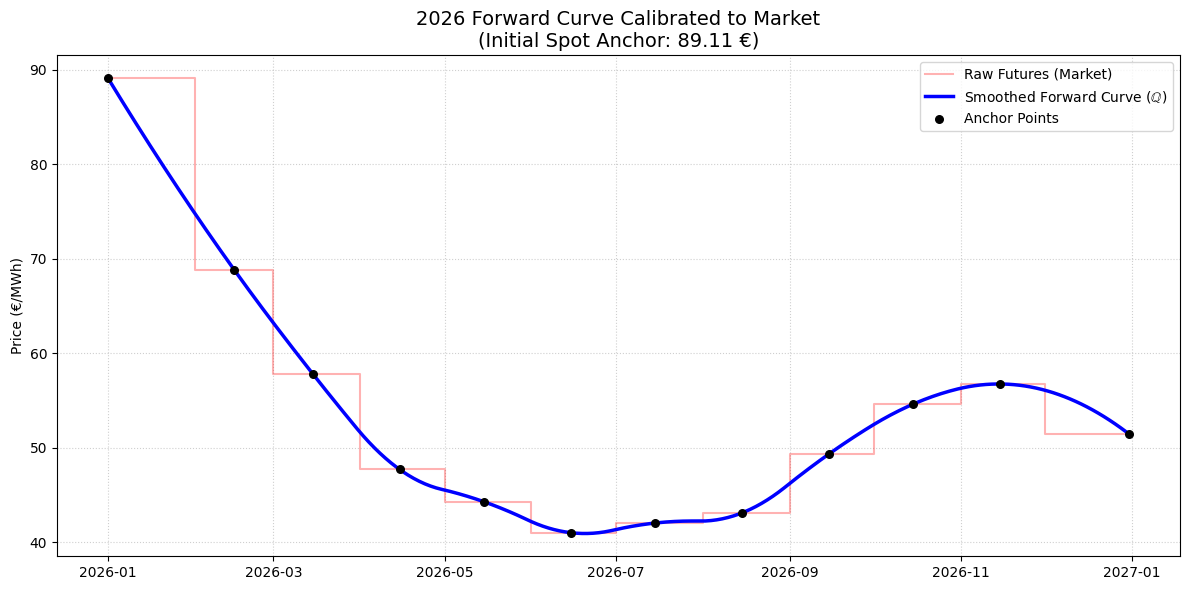

In [37]:
# Data Preparation
last_prices = future.iloc[-1]
mapping_2026 = {
    'TRFRBFVMG6': 2,  'TRFRBFVMH6': 3,  'TRFRBFVMJ6': 4,  'TRFRBFVMK6': 5,
    'TRFRBFVMM6': 6,  'TRFRBFVMN6': 7,  'TRFRBFVMQ6': 8,  'TRFRBFVMU6': 9,
    'TRFRBFVMV6': 10, 'TRFRBFVMX6': 11, 'TRFRBFVMZ6': 12
}

# Spot price as of 31/12/2025
spot_merged['date'] = pd.to_datetime(spot_merged['date'])
spot_val = spot_merged[spot_merged['date'] == '2025-12-31']['price'].values[0]

# Construction of the raw forward curve
dates_2026 = pd.date_range('2026-01-01', '2026-12-31', freq='D')
fwd_curve_raw = pd.Series(index=dates_2026, dtype=float)

# Initialize January with the last spot value (or market implied value)
fwd_curve_raw[fwd_curve_raw.index.month == 1] = spot_val

for code, month in mapping_2026.items():
    if code in last_prices.index:
        fwd_curve_raw[fwd_curve_raw.index.month == month] = last_prices[code]

# Quadratic Interpolation (Smoothing)
anchors_dates = [dates_2026[0]] # Jan 1st
anchors_values = [spot_val]

for m in range(2, 12):
    # Use the 15th of each month as a mid-month anchor point
    m_idx = fwd_curve_raw[fwd_curve_raw.index.month == m].index[14]
    anchors_dates.append(m_idx)
    anchors_values.append(fwd_curve_raw[m_idx])

# Add December 31st anchor
anchors_dates.append(dates_2026[-1])
anchors_values.append(fwd_curve_raw[fwd_curve_raw.index.month == 12].iloc[-1])

# Create interpolation function
x_anchors = np.array([d.to_julian_date() for d in anchors_dates])
y_anchors = np.array(anchors_values)
f_smooth = interp1d(x_anchors, y_anchors, kind='quadratic', fill_value="extrapolate")

# Generate smoothed values for all dates
x_all = np.array([d.to_julian_date() for d in dates_2026])
fwd_values_2026 = f_smooth(x_all) # Final vector for Monte Carlo simulation

# Visualization
plt.figure(figsize=(12, 6))

# Red lines (Raw Futures Levels)
plt.step(fwd_curve_raw.index, fwd_curve_raw.values, where='post',
         color='red', alpha=0.3, label='Raw Futures (Market)')

# Blue line (Smoothed Q Curve)
plt.plot(dates_2026, fwd_values_2026, color='blue', lw=2.5, label='Smoothed Forward Curve ($\mathbb{Q}$)')

# Anchor points
plt.scatter(anchors_dates, anchors_values, color='black', s=30, zorder=5, label='Anchor Points')

plt.title(f"2026 Forward Curve Calibrated to Market\n(Initial Spot Anchor: {spot_val:.2f} €)", fontsize=14)
plt.ylabel("Price (€/MWh)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 7. Monte Carlo Simulation: MRJD & Forward Matching

The `simulate_spot_mrjd` function generates Spot price paths $S(t)$ under the **Risk-Neutral Measure** $\mathbb{Q}$.

To ensure the model is arbitrage-free and consistent with market expectations, we do not simulate $S(t)$ directly. Instead, we simulate a centered stochastic factor $X_t$ and then map it to the observed Forward Curve $\Lambda(t)$.

#### A. Dynamics of the Stochastic Factor $X_t$
The process $X_t$ represents the de-seasonalized log-return driver. It follows a **Mean-Reverting Jump Diffusion (MRJD)** process, discretized as follows:

$$
X_{t+\Delta t} = \underbrace{X_t e^{-\alpha \Delta t}}_{\text{Mean Reversion}} + \underbrace{\sigma \sqrt{\Delta t} \cdot \varepsilon_t}_{\text{Diffusion}} + \underbrace{\sum_{i=1}^{N_{\Delta t}} J_i}_{\text{Jumps}}
$$

Where:
* **$\alpha$** (`mr_alpha`): Speed of mean reversion.
* **$\varepsilon_t \sim \mathcal{N}(0,1)$**: Standard Brownian motion increment.
* **$N_{\Delta t} \sim \text{Poisson}(\lambda \Delta t)$**: Number of jumps occurring in the time step.
* **$J_i \sim \mathcal{N}(\mu_J, \sigma_J^2)$**: Amplitude of each jump.



#### B. Forward Matching (Risk-Neutral Calibration)
Standard models define $S_t = \exp(f(t) + X_t)$. However, calculating the deterministic drift $f(t)$ analytically is complex due to convexity adjustments ($\frac{1}{2}\sigma^2$) and the jump compensator.

Instead, we use a **Forward Matching** technique. We force the expectation of the simulated prices to align exactly with the market Forward Curve $F(0, t)$:

$$
S(t) = F(0, t) \times \frac{e^{X_t}}{\mathbb{E}^{\mathbb{Q}}[e^{X_t}]}
$$

**In the code:**
1.  We compute `X_exp = np.exp(X)`.
2.  We calculate the empirical mean across all paths: `E_X_exp`.
3.  We apply the adjustment: `S = fwd_array * (X_exp / E_X_exp)`.

This guarantees that $\mathbb{E}[S(t)] = F(0, t)$, capturing implicitly the market price of risk and the seasonality without requiring explicit calibration of a premium parameter.

In [38]:
def simulate_spot_mrjd(n_paths, n_days, start_t, params, fwd_array):
    """
    Simulates Spot Price S(t) calibrated to the Forward Curve (Risk-Neutral Measure Q).
    Uses drift adjustment to incorporate the risk premium implicitly.
    """
    # Unpack parameters
    mr_alpha = params['mr_alpha']  # Mean Reversion Speed (Annual)
    sigma    = params['sigma']     # Volatility (Daily or scaled by sqrt(dt))
    lam      = params['lambda']    # Jump Intensity (Annual)
    mu_j     = params['mu_j']      # Mean Jump Size
    sig_j    = params['sigma_j']   # Jump Size Volatility

    dt = 1.0 / 365
    X = np.zeros((n_paths, n_days))

    # 1. Simulation of the Stochastic Factor X(t)
    for t in range(1, n_days):
        # Diffusion part (Brownian Motion)
        z = np.random.normal(0, 1, n_paths)
        diffusion = sigma * z

        # Jump part (Compound Poisson Process)
        n_jumps = np.random.poisson(lam * dt, n_paths)
        # Sum of normals: Mean = N * mu, Std = sqrt(N) * sigma
        jump_val = np.random.normal(n_jumps * mu_j, np.sqrt(n_jumps) * sig_j)

        # Euler discretization of the Mean-Reverting Process
        # Note: Using the exact solution form for the drift: X(t-1) * e^(-alpha*dt)
        X[:, t] = X[:, t-1] * np.exp(-mr_alpha * dt) + diffusion + jump_val

    # 2. Risk Premium Adjustment (Drift Adjustment)
    # We recenter exp(X) around its own empirical mean to isolate the stochastic profile
    X_exp = np.exp(X)
    E_X_exp = np.mean(X_exp, axis=0) # Expectation across all paths at each time step

    # 3. Final Reconstruction on the Market Forward Curve
    # S(t) = F(0,t) * ( exp(X(t)) / E[exp(X(t))] )
    # This forces the expectation of simulated prices to exactly match the Forward Curve
    S = fwd_array[np.newaxis, :] * (X_exp / E_X_exp)

    return S

In [39]:
n_paths = 10000
start_t_sim = 0.0
n_days_sim = 365

# Run the Monte Carlo Simulation
paths_2026 = simulate_spot_mrjd(n_paths, n_days_sim, start_t_sim, my_params, fwd_values_2026)

# Verification / Sanity Check
print("Simulation complete. Shape:", paths_2026.shape)
print(f"Min Simulated Price: {paths_2026.min():.2f}")
print(f"Max Simulated Price: {paths_2026.max():.2f}")
print(f"Mean Simulated Price: {paths_2026.mean():.2f}")

Simulation complete. Shape: (10000, 365)
Min Simulated Price: 1.70
Max Simulated Price: 1447.33
Mean Simulated Price: 53.41


<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/d3/08gxms8j7zq9sxn5lh0v48s80000gn/T/ipykernel_6287/3268734671.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(days, np.exp(mu_t_trend), color='red', linestyle='--', lw=2, label='Historical Seasonality $\exp(\mu(t))$')


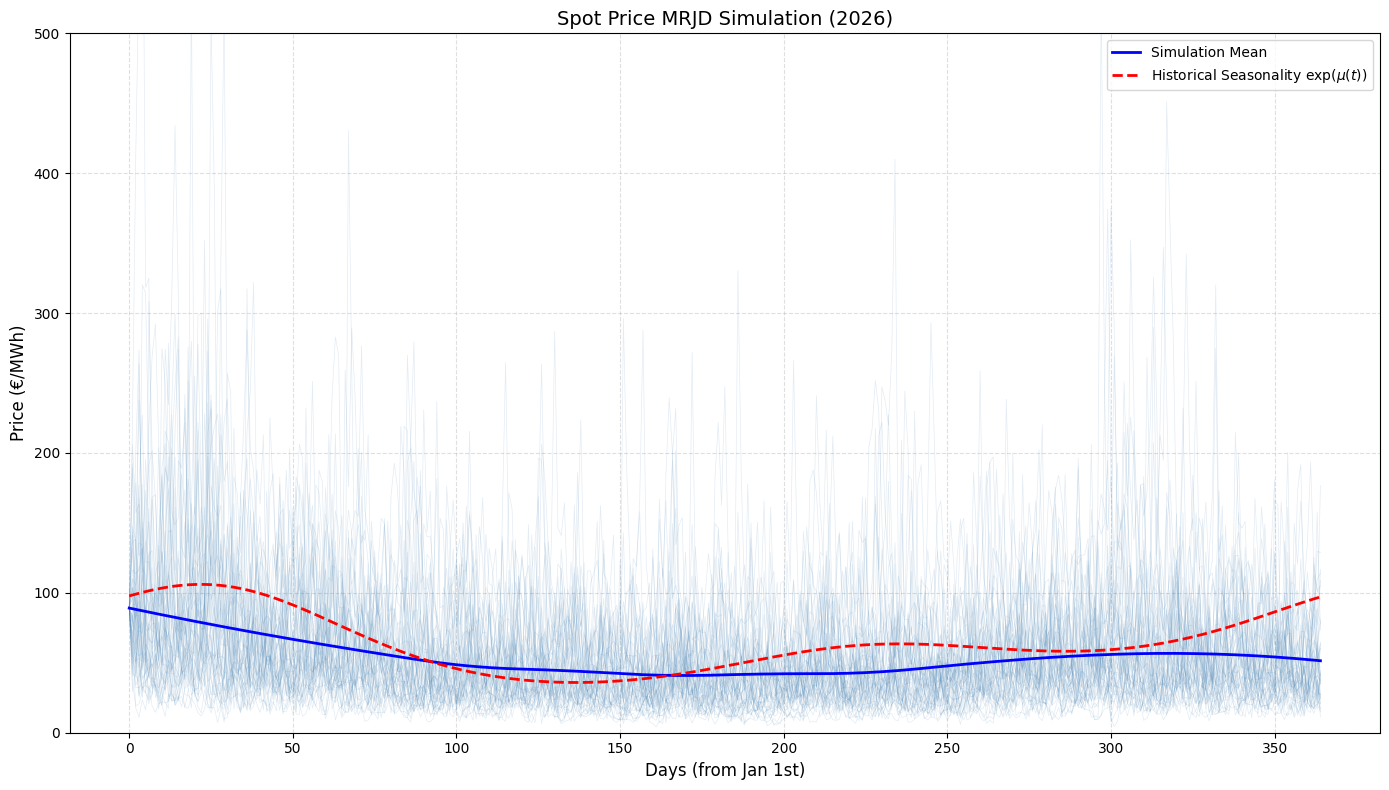

In [40]:
plt.figure(figsize=(14, 8))
days = np.arange(n_days_sim)

# Plot a sample of paths (first 50 trajectories)
plt.plot(days, paths_2026[:50, :].T, color='steelblue', alpha=0.15, lw=0.5)

# Monte Carlo Mean
plt.plot(days, np.mean(paths_2026, axis=0), color='blue', lw=2, label='Simulation Mean')

# Historical Seasonal Trend
t_grid_plot = start_t_sim + days / 365
mu_t_trend = seasonality_func(t_grid_plot,
                              my_params['seas_alpha'], my_params['seas_gamma'],
                              my_params['seas_epsilon'], my_params['seas_delta'], my_params['seas_zeta'])

plt.plot(days, np.exp(mu_t_trend), color='red', linestyle='--', lw=2, label='Historical Seasonality $\exp(\mu(t))$')

y_ticks = np.arange(0, 1101, 100)
plt.yticks(y_ticks)
plt.ylim(0, 500)

plt.title(f"Spot Price MRJD Simulation (2026)", fontsize=14)
plt.xlabel("Days (from Jan 1st)", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4, linestyle='--', which='both')
plt.tight_layout()
plt.show()

## Part II: Pricing the Swing Option

A **Swing Option** allows the holder to purchase energy at a fixed strike price $K$ with flexibility on the volume, subject to strictly defined constraints. Unlike a standard European option, the holder faces multiple exercise decisions throughout the contract period.

The objective is to determine the optimal exercise strategy $u_t$ (volume taken at time $t$) that maximizes the total expected payoff:

$$V_0 = \sup_{u \in \mathcal{U}} \mathbb{E}^{\mathbb{Q}} \left[ \sum_{t=1}^{T} e^{-r t} \cdot u_t \cdot (S_t - K) \right]$$

Subject to:
* **Daily Constraints:** $u_{\min} \leq u_t \leq u_{\max}$
* **Global Constraints:** $Q_{\min} \leq \sum u_t \leq Q_{\max}$

In [41]:
class SwingContract:
    def __init__(self, start_date, n_days, strike, min_daily=0, max_daily=1, min_annual=50, max_annual=250):
        self.start_date = start_date
        self.n_days = n_days
        self.strike = strike
        self.min_daily = min_daily
        self.max_daily = max_daily
        self.min_annual = min_annual
        self.max_annual = max_annual

### 1. Pricing function

This section details the implementation of the `value_swing_option` function. It adapts the classic **Longstaff-Schwartz (2001)** method to **Swing** options by introducing a second state variable: the **cumulative volume** ($Q_t$).

#### 1. Problem Definition
The value of the Swing option at time $t$ depends on two stochastic factors:
1.  The underlying price (Spot): $S_t$.
2.  The volume of electricity already consumed: $Q_t$.

The contract imposes local (daily) and global (annual) constraints:
* **Strike**: $K$
* **Daily Exercise**: $q_t \in \{q_{min}, \dots, q_{max}\}$
* **Terminal Volume**: $Q_{min} \le Q_T \le Q_{max}$

#### 2. Phase 1: Backward Induction
The algorithm moves backward in time from $t=T$ to $t=0$ to learn the optimal strategy.

**A. State Space Discretization**
The continuous cumulative volume is discretized on a grid of $M$ points:
$$
\mathcal{V} = \{v_0, v_1, \dots, v_M \} \subset [0, Q_{max}]
$$

**B. Bellman Equation**
At each date $t$ and for each volume level $v \in \mathcal{V}$, we seek the decision $q$ that maximizes the sum of the immediate payoff and the discounted continuation value:

$$
V_t(S_t, v) = \max_{q \in [q_{min}, q_{max}]} \left( \Phi(S_t, q) + e^{-r\Delta t} \cdot \mathbb{E}^{\mathbb{Q}} \left[ V_{t+1}(S_{t+1}, v+q) \mid S_t \right] \right)
$$

Where:
* $\Phi(S_t, q) = q \times (S_t - K)$ is the immediate payoff.
* The conditional expectation $\mathbb{E}^{\mathbb{Q}}[\dots]$ is estimated via a **polynomial regression** on $S_t$.
* The future value $V_{t+1}(S_{t+1}, v+q)$ is obtained by **linear interpolation** if $v+q$ does not fall exactly on the grid $\mathcal{V}$.

#### 3. Phase 2: Forward Pass
To obtain an unbiased price and a confidence interval, a new simulation is launched from $t=0$ to $T$ using the learned strategies (regression coefficients $\beta$).

**Option Price:**
$$
\hat{P}_{swing} = \frac{1}{N_{sim}} \sum_{i=1}^{N_{sim}} \left( \sum_{t=0}^{T} e^{-rt} \Phi(S_t^{(i)}, q_t^*) - \text{Penalties}(Q_T^{(i)}) \right)
$$

**95% Confidence Interval:**
$$
CI_{95\%} = \left[ \hat{P}_{swing} - 1.96 \frac{\hat{\sigma}}{\sqrt{N_{sim}}} \; ; \; \hat{P}_{swing} + 1.96 \frac{\hat{\sigma}}{\sqrt{N_{sim}}} \right]
$$

In [42]:
def value_swing_option(contract, price_paths, discount_rate=0.04, poly_degree=3):
    """
    LSMC valuation with Forward Pass
    """
    n_paths, n_steps = price_paths.shape
    dt = 1/365
    df = np.exp(-discount_rate * dt)

    # --- PARAMETERS ---
    # Define possible cumulative volumes.
    # For Swing, typically start at 0 and accumulate up to MaxAnnual.
    volumes = np.linspace(0, contract.max_annual, 50)
    n_vols = len(volumes)

    # Possible actions (e.g., 0 or 1 MWh/day)
    possible_q = [contract.min_daily, contract.max_daily]

    # Structures to store the strategy (Betas)
    # Store regression coefficients for each time step and volume level
    stored_betas = []

    # PHASE 1: BACKWARD INDUCTION (Strategy learning)


    # Terminal values (t=T): Penalty if volume < min_annual
    values = np.zeros((n_paths, n_vols))
    penalty_price = 1000
    under_min_mask = volumes < contract.min_annual
    values[:, under_min_mask] = -penalty_price * (contract.min_annual - volumes[under_min_mask])

    # Loop from t = T-1 to 0
    for t in range(n_steps - 2, -1, -1):
        prices = price_paths[:, t]

        # Polynomial regression basis
        # P_basis: matrix (n_paths, degree+1)
        P_basis = np.vander(prices, poly_degree + 1)

        step_betas = np.zeros((n_vols, poly_degree + 1))
        continuation_surface = np.zeros((n_paths, n_vols))

        # Regression for each volume level
        for v_idx in range(n_vols):
            # Discounted values
            y = values[:, v_idx] * df

            # Compute betas
            beta, _, _, _ = np.linalg.lstsq(P_basis, y, rcond=None)
            step_betas[v_idx, :] = beta

            # Estimated continuation value
            continuation_surface[:, v_idx] = P_basis @ beta

        stored_betas.append(step_betas)

        # Value update (Optimization)
        new_values = np.full((n_paths, n_vols), -1e9)
        payoff_immediat = prices - contract.strike

        for v_idx, v in enumerate(volumes):
            for q in possible_q:
                v_next = v + q
                if v_next > contract.max_annual: continue

                # Continuation value interpolation
                idx_low = np.searchsorted(volumes, v_next, side='right') - 1
                idx_low = np.clip(idx_low, 0, n_vols - 2)
                w = (v_next - volumes[idx_low]) / (volumes[idx_low+1] - volumes[idx_low]) if (volumes[idx_low+1] - volumes[idx_low]) > 0 else 0

                val_cont = (1-w)*continuation_surface[:, idx_low] + w*continuation_surface[:, idx_low+1]

                total_val = q * payoff_immediat + val_cont
                new_values[:, v_idx] = np.maximum(new_values[:, v_idx], total_val)

        values = new_values

    # Reorder betas chronologically (0 -> T)
    stored_betas.reverse()

    # PHASE 2: FORWARD PASS (Real simulation for CI)

    # Reset to zero to calculate real cashflows
    cashflows = np.zeros(n_paths)
    current_volumes = np.zeros(n_paths) # Everyone starts at 0

    # Cumulative discount factor
    cum_df = 1.0

    for t in range(n_steps - 1):
        prices = price_paths[:, t]
        betas_t = stored_betas[t] # (n_vols, degree+1)

        # Regression basis for current price
        P_current = np.vander(prices, poly_degree + 1)

        # Calculate immediate payoffs and decision
        payoff_unit = prices - contract.strike

        # Decision for each path
        for i in range(n_paths):
            vol = current_volumes[i]

            # If contract filled, stop (or do nothing)
            if vol >= contract.max_annual:
                continue

            # Estimate Continuation Value for q=0 (Wait) vs q=1 (Exercise)
            # 1. Value if waiting (vol does not change)

            # --- Fast calculation of local continuation surface ---
            # Ideally vectorized, simple loop here for clarity

            # Find volume indices bounding current volume
            idx = np.searchsorted(volumes, vol, side='right') - 1
            idx = np.clip(idx, 0, n_vols - 2)
            w = (vol - volumes[idx]) / (volumes[idx+1] - volumes[idx])

            # Continuation values at bounds (Wait)
            cont_val_low = np.dot(P_current[i], betas_t[idx])
            cont_val_high = np.dot(P_current[i], betas_t[idx+1])
            val_wait = (1-w)*cont_val_low + w*cont_val_high

            # Continuation values if exercising (vol + q_max)
            # Assume q_choice = max_daily
            q_choice = contract.max_daily
            vol_next = vol + q_choice

            if vol_next <= contract.max_annual:
                idx_n = np.searchsorted(volumes, vol_next, side='right') - 1
                idx_n = np.clip(idx_n, 0, n_vols - 2)
                w_n = (vol_next - volumes[idx_n]) / (volumes[idx_n+1] - volumes[idx_n])

                cont_val_low_ex = np.dot(P_current[i], betas_t[idx_n])
                cont_val_high_ex = np.dot(P_current[i], betas_t[idx_n+1])
                val_cont_ex = (1-w_n)*cont_val_low_ex + w_n*cont_val_high_ex

                val_exercise = (q_choice * payoff_unit[i]) + val_cont_ex

                # Comparison
                # Note: Stored betas are already the "discounted value" of the next step.
                # So compare directly.

                if val_exercise > val_wait:
                    # Exercise
                    cashflows[i] += q_choice * payoff_unit[i] * cum_df
                    current_volumes[i] += q_choice

        cum_df *= df

    # Final penalty for those who didn't reach min
    penalty_mask = current_volumes < contract.min_annual
    cashflows[penalty_mask] -= penalty_price * (contract.min_annual - current_volumes[penalty_mask]) * cum_df

    # ==============================================================================
    # STATISTICAL RESULTS
    # ==============================================================================
    price = np.mean(cashflows)
    std_dev = np.std(cashflows)
    std_err = std_dev / np.sqrt(n_paths)
    conf_interval = (price - 1.96 * std_err, price + 1.96 * std_err)

    return price, std_err, conf_interval, stored_betas, volumes

### 2. Results

The results below represent the fair value of the Swing contract estimated using the **Longstaff-Schwartz (LSM)** algorithm based on the Mean-Reverting Jump Diffusion simulations.

#### 1. Simulation Setup
* **Underlying Model:** MRJD (calibrated to Market Forward Curve).
* **Monte Carlo Accuracy:** $M = 10,000$ paths.
* **LSM Discretization:** The volume constraint (global quantity) was discretized into a grid of **50 points** to approximate the value function/continuation value.

#### 2. Pricing Metrics
| Metric | Value | Unit |
| :--- | :--- | :--- |
| **Swing Option Value ($V_0$)** | **2,303.52** | **EUR** |
| Standard Error (SE) | 8.44 | EUR |
| Relative Error | $\approx 0.37\%$ | % |
| **95% Confidence Interval** | $[2,286.98, \ 2,320.06]$ | EUR |



#### 3. Interpretation
* **The Fair Premium:** The value of **2,303.52 €** represents the expected discounted profit under the optimal exercise strategy. This includes the **Intrinsic Value** (average spread $S_t - K$) and the **Extrinsic Value** (the flexibility premium: the ability to withhold exercise when prices are low and maximize volume when prices spike).
* **Convergence Quality:** With a standard error of $\approx 8.44$ €, the estimation is precise enough for pricing purposes. The true value lies within the confidence interval with 95% probability:
    $$V_{true} \in \left[ \bar{V}_N - 1.96 \frac{\sigma_N}{\sqrt{N}}, \ \bar{V}_N + 1.96 \frac{\sigma_N}{\sqrt{N}} \right]$$

In [43]:
# 1. Initialize Swing Contract
swing_contract = SwingContract(
    start_date='2026-01-01',
    n_days=n_days_sim,
    strike=80.0,
    min_daily=0,
    max_daily=1,
    min_annual=50,
    max_annual=250
)

# 2. Run Valuation
price_final, std_err, conf_int, model_betas, volume_grid = value_swing_option(
    swing_contract,
    paths_2026,
    poly_degree=3
)

# 3. Display Results (including statistical metrics)
print("-" * 60)
print(f"VALUATION RESULTS (MRJD Model)")
print("-" * 60)
print(f"Number of Paths        : {n_paths}")
print(f"Contract Duration      : {n_days_sim} days")
print(f"Strike Price           : {swing_contract.strike} EUR/MWh")
print("-" * 60)
print(f"SWING OPTION VALUE     : {price_final:.4f} EUR")
print(f"Standard Error (SE)    : {std_err:.4f}")
print(f"95% Conf. Interval     : [{conf_int[0]:.4f}, {conf_int[1]:.4f}] EUR")
print("-" * 60)

print(f"Volume Grid Size       : {len(volume_grid)} points")

------------------------------------------------------------
VALUATION RESULTS (MRJD Model)
------------------------------------------------------------
Number of Paths        : 10000
Contract Duration      : 365 days
Strike Price           : 80.0 EUR/MWh
------------------------------------------------------------
SWING OPTION VALUE     : 2312.4945 EUR
Standard Error (SE)    : 8.5220
95% Conf. Interval     : [2295.7913, 2329.1977] EUR
------------------------------------------------------------
Volume Grid Size       : 50 points


### 3. Sensitivity Analysis: The Greeks

The `greeks_analysis` function assesses the sensitivity of the Swing option price to market parameters. It calculates the **Delta** ($\Delta$) and **Vega** ($\mathcal{V}$) using finite difference methods and visualizes the results.

#### 1. Delta Calculation ($\Delta$)
The Delta measures the rate of change of the option value with respect to the spot price of the underlying asset.

* **Methodology:** We use a **Pathwise Shift** approach. Instead of running new simulations (which would introduce variance), we shift the existing price paths $S_t$ by a small factor $\epsilon$ ($1\%$).
* **Formula (Central Difference):**
  $$
  \Delta \approx \frac{P(S_0(1+\epsilon)) - P(S_0(1-\epsilon))}{2 \cdot S_0 \cdot \epsilon}
  $$
  Where $P(\cdot)$ is the pricing function and $S_0$ is the initial spot price. This method is computationally efficient and reduces variance.

#### 2. Vega Calculation ($\mathcal{V}$)
The Vega measures the sensitivity to the volatility $\sigma$.

* **Methodology:** We use a **Bump and Revalue** approach with **Common Random Numbers (CRN)**.
* **CRN Technique:** Since volatility affects the diffusion process itself, we must regenerate the paths. To isolate the impact of volatility from Monte Carlo noise, we fix the random `seed`. This ensures that the random shocks ($dW_t$) remain identical between the scenarios $\sigma + \epsilon$ and $\sigma - \epsilon$.
* **Formula:**
  $$
  \mathcal{V} \approx \frac{P(\sigma + \epsilon_{abs}) - P(\sigma - \epsilon_{abs})}{2}
  $$
  The result interprets the price change for a $1\%$ absolute change in volatility (e.g., from $50\%$ to $51\%$).

In [29]:
def greeks_analysis(contract, base_paths, base_params, fwd_curve, pricing_func, sim_func):
    """
    Delta and Vega calculation + Plotting.
    """
    # 1. Preparation
    S0 = base_paths[0, 0]             # Current Spot Price (t=0)
    sigma_base = base_params['sigma'] # Current Volatility

    # A. DELTA CALCULATION (Sensitivity to Spot Price)
    # We shift the existing paths by +/- 1%
    bump_spot = 0.01 # 1%

    # Retrieve only the first element of the return tuple (the price) using [0]
    p_spot_up   = pricing_func(contract, base_paths * (1 + bump_spot))[0]
    p_spot_down = pricing_func(contract, base_paths * (1 - bump_spot))[0]

    # Delta Formula
    delta = (p_spot_up - p_spot_down) / (2 * S0 * bump_spot)

    print(f"1. DELTA : {delta:.4f}")

    # B. VEGA CALCULATION (Sensitivity to Volatility)
    # Method: Re-simulate with sigma +/- 1% (using the same random seed)
    bump_vol = 0.01 # +1% absolute
    seed = 42

    p_up = copy.deepcopy(base_params); p_up['sigma'] += bump_vol
    p_dn = copy.deepcopy(base_params); p_dn['sigma'] -= bump_vol

    # Simulation
    np.random.seed(seed)
    paths_vol_up = sim_func(base_paths.shape[0], base_paths.shape[1], 0.0, p_up, fwd_curve)

    np.random.seed(seed)
    paths_vol_dn = sim_func(base_paths.shape[0], base_paths.shape[1], 0.0, p_dn, fwd_curve)

    np.random.seed(None)

    # Pricing
    price_vol_up = pricing_func(contract, paths_vol_up)[0]
    price_vol_down = pricing_func(contract, paths_vol_dn)[0]

    # Vega (Impact for 1% change in vol)
    vega = (price_vol_up - price_vol_down) / 2

    print(f"2. VEGA  : {vega:.4f}")

    # C. PLOTTING

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Graph 1: Price vs Spot
    factors = np.linspace(0.7, 1.3, 10) # +/- 30% around the spot
    prices_s = [pricing_func(contract, base_paths * f)[0] for f in factors]

    ax1.plot(S0 * factors, prices_s, 'b-o')
    ax1.set_title("Delta Profile (Price vs Spot)")
    ax1.set_xlabel("Spot Price (€)"); ax1.set_ylabel("Option Price (€)")
    ax1.axvline(S0, c='r', ls='--', alpha=0.5, label='Current Spot')
    ax1.legend()

    # Graph 2: Price vs Vol
    vols_test = np.linspace(sigma_base - 0.1, sigma_base + 0.1, 10) # +/- 10% vol
    prices_v = []

    np.random.seed(seed) # Fix seed for a clean plot
    for v in vols_test:
        pt = copy.deepcopy(base_params); pt['sigma'] = v
        path_tmp = sim_func(base_paths.shape[0], base_paths.shape[1], 0.0, pt, fwd_curve)
        prices_v.append(pricing_func(contract, path_tmp)[0])
    np.random.seed(None)

    ax2.plot(vols_test, prices_v, 'g-s')
    ax2.set_title("Vega Profile (Price vs Volatility)")
    ax2.set_xlabel("Volatility (sigma)"); ax2.set_ylabel("Option Price (€)")
    ax2.axvline(sigma_base, c='r', ls='--', alpha=0.5, label='Current Vol')
    ax2.legend()

    plt.tight_layout()
    plt.show()

1. DELTA : 609.7408
2. VEGA  : 445.7040


KeyboardInterrupt: 

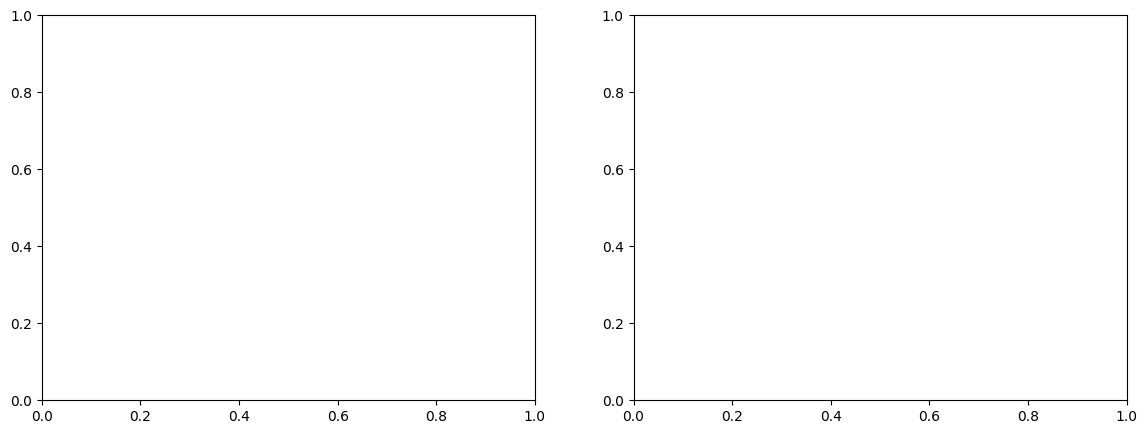

In [30]:
greeks_analysis(
    swing_contract,
    paths_2026,
    my_params,
    fwd_values_2026,
    value_swing_option,
    simulate_spot_mrjd
)